In [518]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

In [519]:
df = pd.read_csv("reddit_features.csv")

In [520]:
drop_cols = ["viral", "score", "awards", "url", "title", "subreddit", "num_comments"]

In [521]:
x = df.drop(columns=drop_cols)
y = df["viral"]

In [522]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [523]:
model = xgb.XGBClassifier(scale_pos_weight=3)

In [524]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [525]:
y_pred = model.predict(x_test)

In [526]:
print(accuracy_score(y_test, y_pred))

0.715


In [527]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       151
           1       0.39      0.31      0.34        49

    accuracy                           0.71       200
   macro avg       0.59      0.58      0.58       200
weighted avg       0.69      0.71      0.70       200



In [528]:
print(confusion_matrix(y_test, y_pred))

[[128  23]
 [ 34  15]]


In [529]:
scores = cross_val_score(model, x, y, cv=5)
print(scores.mean())

0.6849999999999999


In [530]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=5
)

In [531]:
model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [532]:
y_prob = model.predict_proba(x_test)[:,1]
y_pred = (y_prob > 0.35).astype(int)

In [533]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.56      0.69       151
           1       0.37      0.78      0.50        49

    accuracy                           0.61       200
   macro avg       0.63      0.67      0.59       200
weighted avg       0.76      0.61      0.64       200



In [534]:
x.columns

Index(['upvote_ratio', 'created_utc', 'is_self', 'post_hour', 'post_day',
       'is_weekend', 'title_words_count', 'has_question', 'has_number',
       'controversy_index', 'sentiment_score', 'is_extreme_sentiment'],
      dtype='object')

In [535]:
model.feature_importances_

array([0.10797046, 0.06124691, 0.16758929, 0.07620258, 0.06744378,
       0.        , 0.08682525, 0.13580433, 0.06840444, 0.11910689,
       0.08668831, 0.02271772], dtype=float32)

In [536]:
model_rf = RandomForestClassifier(class_weight="balanced")

In [537]:
model_rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [538]:
y_probrf = model_rf.predict_proba(x_test)[:,1]
y_predrf = (y_probrf > 0.35).astype(int)

In [539]:
print(classification_report(y_test, y_predrf))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       151
           1       0.34      0.37      0.35        49

    accuracy                           0.67       200
   macro avg       0.56      0.57      0.57       200
weighted avg       0.68      0.67      0.67       200



In [540]:
model_rf.feature_importances_

array([0.08948943, 0.14997187, 0.00970151, 0.12200562, 0.06253029,
       0.01454573, 0.14638388, 0.00392397, 0.02558589, 0.22462391,
       0.13494797, 0.01628992])

In [541]:
import joblib
joblib.dump(model, "xgb_model.pkl")

['xgb_model.pkl']

In [542]:
import shap

In [543]:
explainer = shap.TreeExplainer(model)

In [544]:
shap_values = explainer.shap_values(x_test)

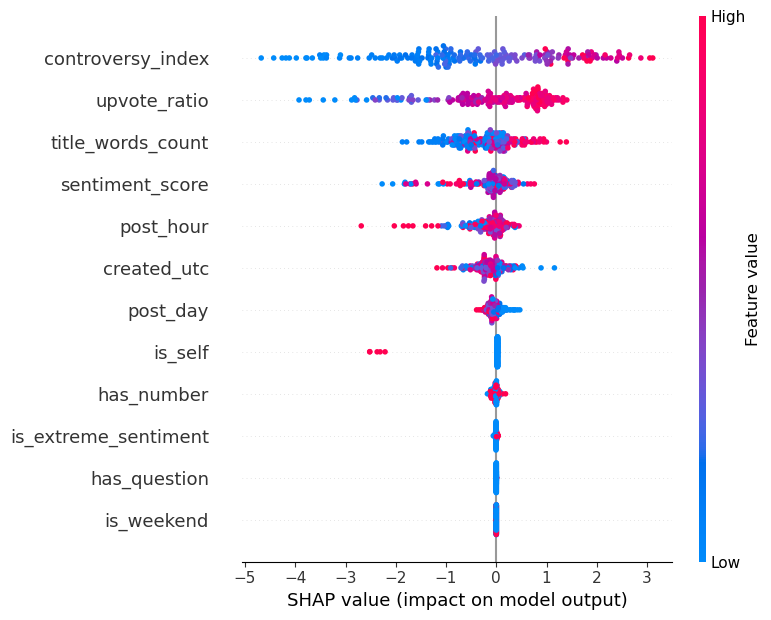

In [545]:
shap.summary_plot(shap_values, x_test)

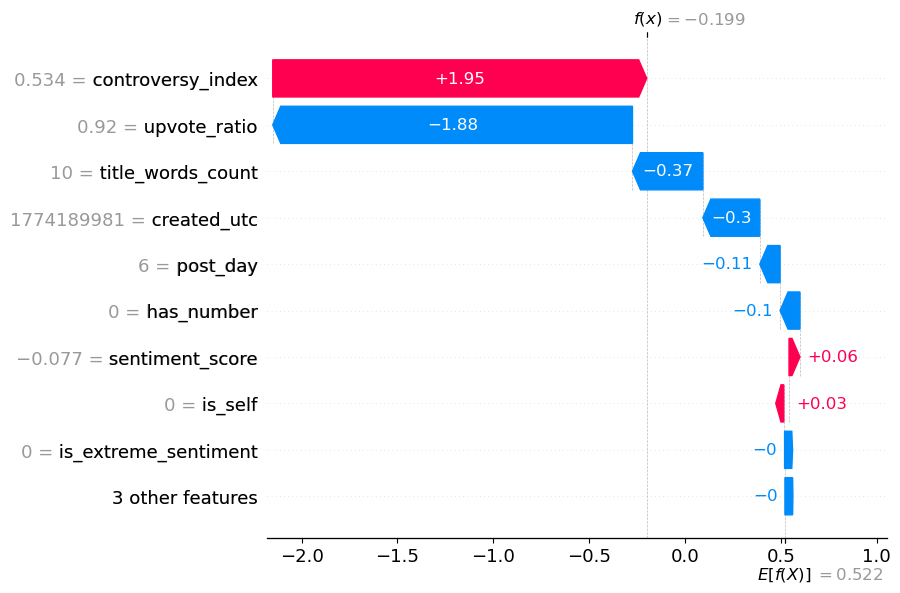

In [546]:
shap.plots.waterfall(explainer(x_test)[0])

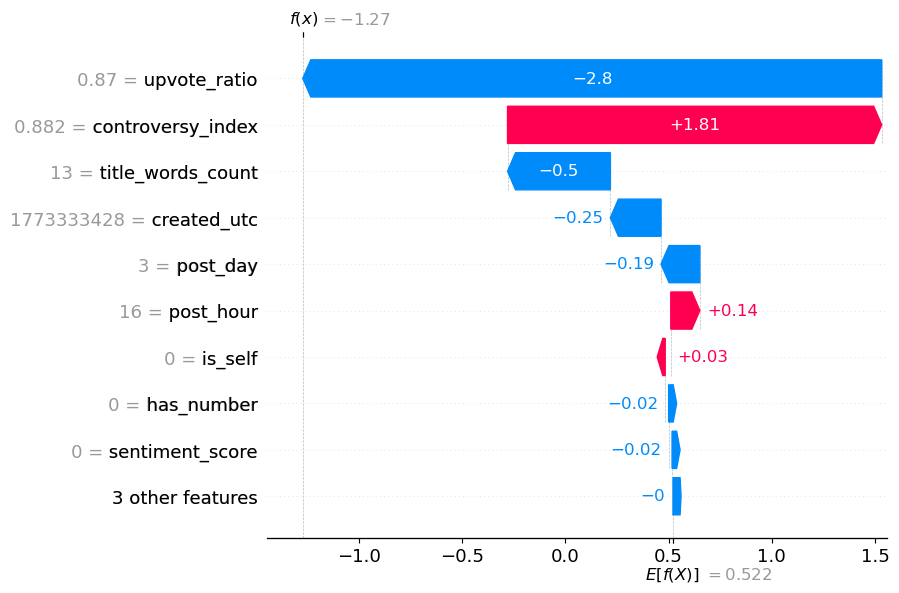

In [547]:
shap.plots.waterfall(explainer(x_test)[1])

- controversy_index is the most important feature for virality prediction
- SHAP waterfall plot shows instance-level explanation why a specific post was predicted viral or not
- High controversy + high upvote_ratio can contradict each other, making prediction non-viral